
**Task 2: Data Cleaning and Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv("C:/Users/david/Downloads/churn-bigml-80.csv")

In [5]:
data.head()
data.tail()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
2665,TN,74,415,No,Yes,25,234.4,113,39.85,265.9,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [7]:
data.shape

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [9]:
data.dtypes


State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

In [11]:
data.describe

<bound method NDFrame.describe of      State  Account length  Area code International plan Voice mail plan  \
0       KS             128        415                 No             Yes   
1       OH             107        415                 No             Yes   
2       NJ             137        415                 No              No   
3       OH              84        408                Yes              No   
4       OK              75        415                Yes              No   
...    ...             ...        ...                ...             ...   
2661    SC              79        415                 No              No   
2662    AZ             192        415                 No             Yes   
2663    WV              68        415                 No              No   
2664    RI              28        510                 No              No   
2665    TN              74        415                 No             Yes   

      Number vmail messages  Total day minutes  Total

In [13]:
data.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [15]:
#Dropping unnecessary columns
data.drop(['State', 'Area code'], axis=1, inplace=True)

In [17]:
#Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

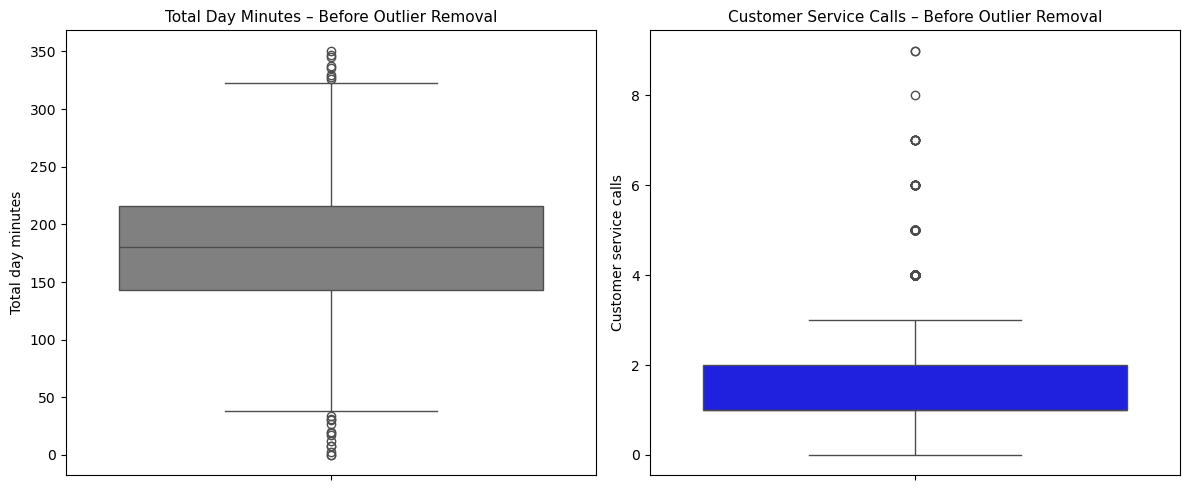

In [19]:
# Visualise before removal of outliers
FIGSIZE = (12, 5)
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].set_title("Total Day Minutes – Before Outlier Removal", fontsize=11)
sns.boxplot(y=data["Total day minutes"], ax=axes[0], color="grey")
axes[1].set_title("Customer Service Calls – Before Outlier Removal", fontsize=11)
sns.boxplot(y=data["Customer service calls"], ax=axes[1], color="blue")
plt.tight_layout()
plt.show()
plt.close()

In [21]:
rows_before = len(data)
outlier_cols = ["Total day minutes", "Customer service calls",
                "Total day charge", "Total intl minutes"]
 
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    data = data[(data[col] >= lower) & (data[col] <= upper)]
    print(f"  '{col}': removed {outliers} outliers  (lower={lower:.2f}, upper={upper:.2f})")
 
print(f"\nRows before: {rows_before}  |  Rows after: {len(data)}  |  Removed: {rows_before - len(data)}")

  'Total day minutes': removed 21 outliers  (lower=34.65, upper=324.65)
  'Customer service calls': removed 209 outliers  (lower=-0.50, upper=3.50)
  'Total day charge': removed 0 outliers  (lower=6.09, upper=55.06)
  'Total intl minutes': removed 34 outliers  (lower=3.10, upper=17.50)

Rows before: 2666  |  Rows after: 2402  |  Removed: 264


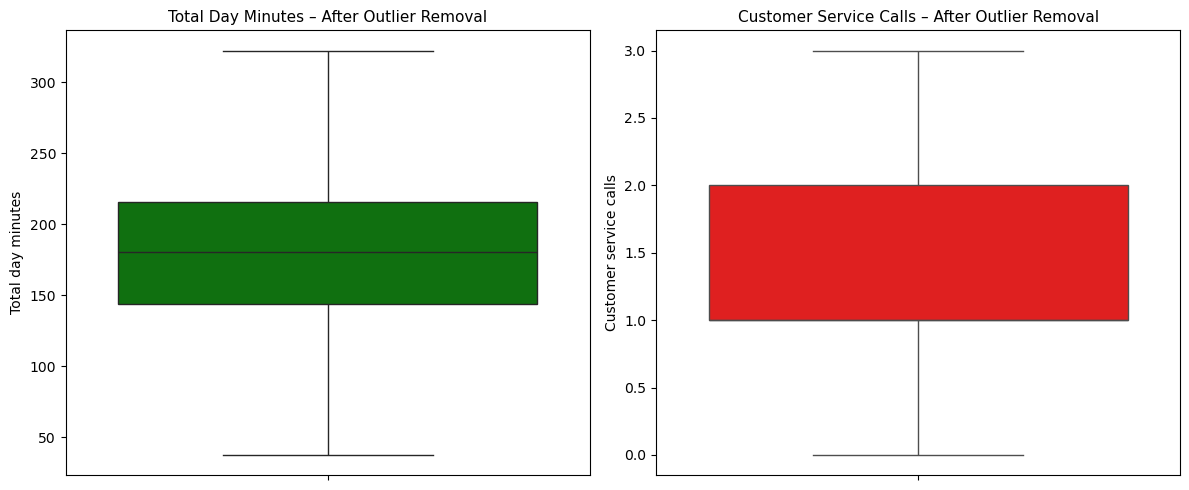

In [23]:
# Visualise after removal of outliers
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].set_title("Total Day Minutes – After Outlier Removal", fontsize=11)
sns.boxplot(y=data["Total day minutes"], ax=axes[0], color="green")
axes[1].set_title("Customer Service Calls – After Outlier Removal", fontsize=11)
sns.boxplot(y=data["Customer service calls"], ax=axes[1], color="red")
plt.tight_layout()
plt.show()
plt.close()

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

data = pd.DataFrame(scaled_data, columns=data.columns)